# Basic Robotics Kinematics with MuJoCo

This tutorial follows the structure of **John J. Craig's *Introduction to Robotics: Mechanics and Control*** (Stanford CS223A), using [MuJoCo](https://mujoco.org/) to illustrate and verify each concept.

We will build up from describing a single rigid body in 3D space all the way to computing the Jacobian of a 3‑link robot arm.

## Prerequisites

```bash
pip install mujoco numpy
```

In [1]:
import os
import subprocess

# Check if installation was succesful.
try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Other imports and helper functions
import time
import itertools
import numpy as np

# Graphics and plotting.
print('Installing mediapy:')
import mediapy as media
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import ipywidgets as widgets


# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()


print(f"MuJoCo {mujoco.__version__}  |  NumPy {np.__version__}")

MuJoCo 3.9.0  |  NumPy 2.4.6


---

## Part 0 · Coordinate Systems and Rigid‑Body Motion

Before we study multi‑link robots, we need to describe **where** an object is and **how it is oriented** in 3D space.  Let's work with a single rigid body first.

### 0.1  A Single Body in MuJoCo

We define a scene with just one box attached to a *free joint*, giving it 6 degrees of freedom — three for translation, three for rotation.

nbody = 2, nv = 6


""

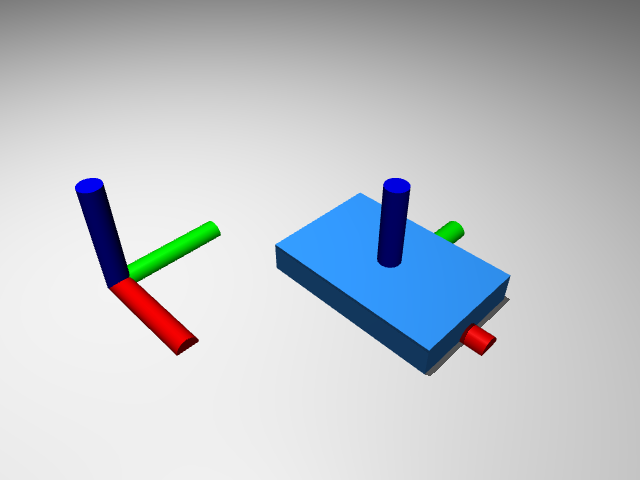

In [2]:
single_body_xml = """
<mujoco model="single_body">
  <worldbody>
    <light name="top" pos="0 0 3"/>
    <geom name="ground" type="plane" size="2 2 0.01" rgba="0.9 0.9 0.9 1"/>
    <body name="block" pos=".3 .3 0">
      <freejoint name="free"/>
      <geom name="block_g" type="box" size="0.15 0.10 0.05" rgba="0.2 0.6 1.0 1"/>
    </body>
  </worldbody>
</mujoco>
"""

sb_model = mujoco.MjModel.from_xml_string(single_body_xml)
sb_data  = mujoco.MjData(sb_model)
print(f"nbody = {sb_model.nbody}, nv = {sb_model.nv}")

# Create and configure visualization options
opt = mujoco.MjvOption()
opt.frame = mujoco.mjtFrame.mjFRAME_GEOM  # This enables geom frames

# Configure camera for broader view
cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.distance = 1.0      # Increase this to zoom out (default ~2-3)
cam.azimuth = 135         # Horizontal angle (degrees)
cam.elevation = -40      # Vertical angle (degrees)
cam.lookat = [.15, .3, 0]   # Center point of the scene

with mujoco.Renderer(sb_model, height=480, width=640) as renderer:
  mujoco.mj_forward(sb_model, sb_data)
  renderer.update_scene(sb_data, scene_option=opt, camera=cam)

  media.show_image(renderer.render())

### 0.2  Cartesian Coordinates — Position (Translation)

The position of a point in 3D space is described by a vector $[x,\, y,\, z]^\top$ relative to a **reference frame**.  The world frame $\{W\}$ is our fixed frame of reference.

In MuJoCo, set the body's position via `data.qpos[:3]` and read it back from `data.xpos`.

Translation vector: Δ = (0.6, -0.3, 0.5)


This browser does not support the video tag.


Initial and Final Posistion:


,

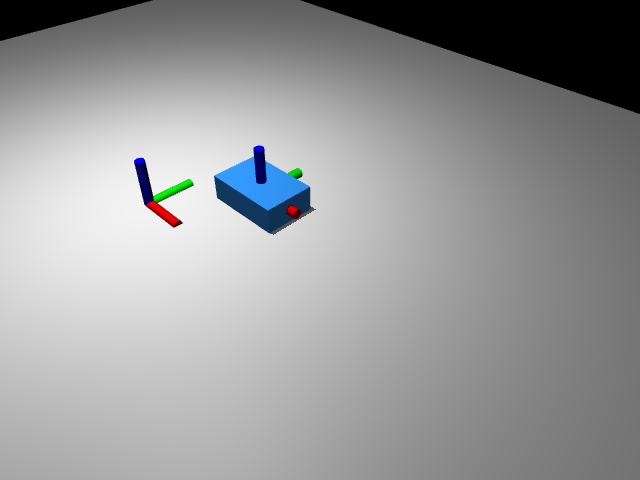
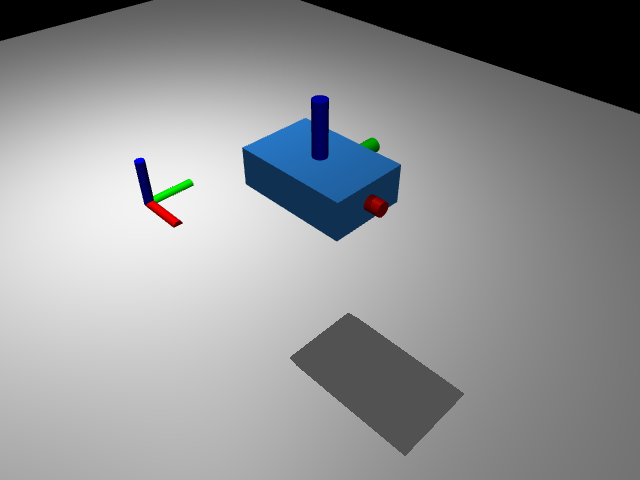

In [3]:
# Pick an initial pose (at .3 .3 0) and a translation, for example 0.7 units to the right.
start_pos = np.array([0.3, 0.3, 0.05])
end_pos   = np.array([0.9, 0.0, 0.55])

# Parameterize the path.
duration = 2
framerate = 30
nframes = int(duration * framerate)

# Use the same sb_model and sb_data from Part 0.1.
# Re‑configure camera for a clear view of the motion.
opt = mujoco.MjvOption()
opt.frame = mujoco.mjtFrame.mjFRAME_GEOM

cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.distance = 2.0
cam.azimuth = 135
cam.elevation = -40
cam.lookat = [0.6, 0.3, 0]

frames = []
with mujoco.Renderer(sb_model, height=480, width=640) as renderer:
    for i in range(nframes):
        t = i / (nframes - 1)                    # 0 → 1
        sb_data.qpos[:3] = start_pos + t * (end_pos - start_pos)
        sb_data.qpos[3:7] = [1, 0, 0, 0]         # identity quaternion
        mujoco.mj_forward(sb_model, sb_data)

        renderer.update_scene(sb_data, scene_option=opt, camera=cam)
        frames.append(renderer.render())

print(f'Translation vector: Δ = ({end_pos[0] - start_pos[0]:.1f}, {end_pos[1] - start_pos[1]:.1f}, {end_pos[2] - start_pos[2]:.1f})')
media.show_video(frames, fps=framerate)
print("Initial and Final Posistion:")
media.show_images([frames[0], frames[-1]])

#### Translation Mapping (frame change)

A **mapping** changes the *reference frame* while the physical point stays still:

$${}^A P = {}^A P_{B\,\text{org}} + {}^B P$$

The point itself has not moved — we are simply describing its position
from a different origin.  The plot below draws both frames {W} and {B}
and the same point expressed in each.

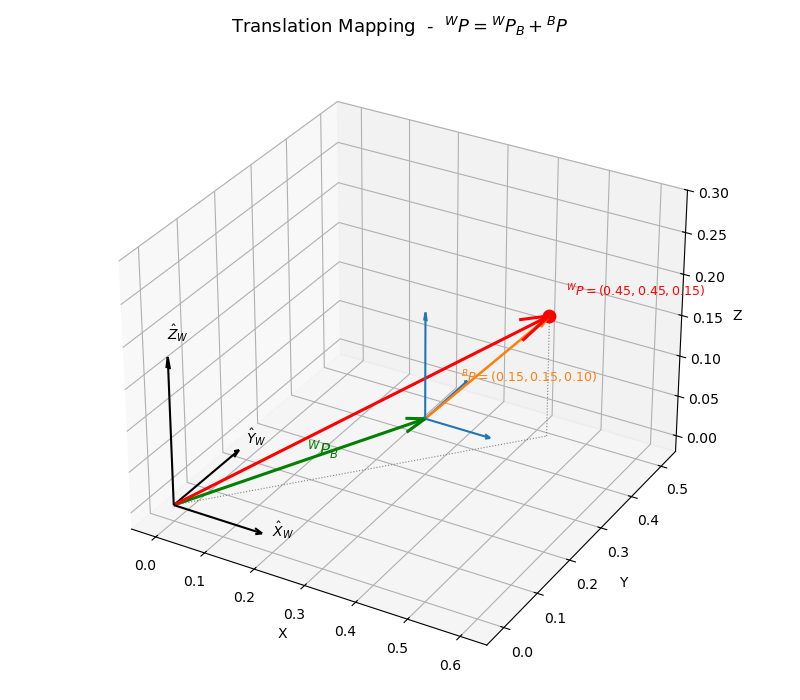

^W P_B  = (np.float64(0.3), np.float64(0.3), np.float64(0.05))
^B P    = (np.float64(0.15), np.float64(0.15), np.float64(0.1))
^W P    = (np.float64(0.45), np.float64(0.45), np.float64(0.15))


In [4]:
# Activate interactive 3-D backend
def plot_translation_mapping(px=0.15, py=0.15, pz=0.15):
    # Translation mapping:  ^W P = ^W P_B + ^B P   (R = I).
    origin_B  = np.array([0.3, 0.3, 0.05])
    p_in_B    = np.array([px,  py,  pz])
    p_in_W    = origin_B + p_in_B

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # ---- world frame {W} ----
    ax.quiver(0, 0, 0, 0.18, 0, 0, color='black', arrow_length_ratio=0.08, lw=1.5)
    ax.quiver(0, 0, 0, 0, 0.18, 0, color='black', arrow_length_ratio=0.08, lw=1.5)
    ax.quiver(0, 0, 0, 0, 0, 0.18, color='black', arrow_length_ratio=0.08, lw=1.5)
    ax.text(0.20, 0.00, 0.00, r'$\hat{X}_W$', fontsize=10)
    ax.text(0.00, 0.20, 0.00, r'$\hat{Y}_W$', fontsize=10)
    ax.text(0.00, 0.00, 0.20, r'$\hat{Z}_W$', fontsize=10)

    # ---- body frame {B} (aligned, shifted) ----
    ax.quiver(*origin_B, 0.13, 0, 0, color='#1f77b4', arrow_length_ratio=0.08, lw=1.5)
    ax.quiver(*origin_B, 0, 0.13, 0, color='#1f77b4', arrow_length_ratio=0.08, lw=1.5)
    ax.quiver(*origin_B, 0, 0, 0.13, color='#1f77b4', arrow_length_ratio=0.08, lw=1.5)

    # ---- ^W P_B (green) ----
    ax.quiver(0, 0, 0, *origin_B, color='green', arrow_length_ratio=0.08, lw=2.2)
    ax.text(origin_B[0]/2, origin_B[1]/2 + 0.02, origin_B[2]/2,
            r'$^W P_B$', color='green', fontsize=12, weight='bold')

    # ---- ^B P (orange, from body origin) ----
    if np.linalg.norm(p_in_B) > 0.001:
        ax.quiver(*origin_B, *p_in_B, color='#ff7f0e', arrow_length_ratio=0.08, lw=1.8)
    ax.text(origin_B[0] + 0.02, origin_B[1] + 0.08, origin_B[2] + 0.02,
            f'$^B P=({px:.2f},{py:.2f},{pz:.2f})$', fontsize=9, color='#ff7f0e')

    # ---- ^W P (red, from world origin) ----
    ax.quiver(0, 0, 0, *p_in_W, color='red', arrow_length_ratio=0.08, lw=2.2)
    ax.scatter(*p_in_W, color='red', s=80, zorder=5)
    ax.text(p_in_W[0] + 0.02, p_in_W[1] + 0.02, p_in_W[2] + 0.02,
            f'$^W P=({p_in_W[0]:.2f},{p_in_W[1]:.2f},{p_in_W[2]:.2f})$',
            fontsize=9, color='red')

    # ---- projection helpers ----
    ax.plot([0, p_in_W[0]], [0, p_in_W[1]], [0, 0], ':', color='gray', lw=0.8)
    ax.plot([p_in_W[0], p_in_W[0]], [p_in_W[1], p_in_W[1]],
            [0, p_in_W[2]], ':', color='gray', lw=0.8)

    ax.set_xlim(-0.05, 0.65)
    ax.set_ylim(-0.05, 0.55)
    ax.set_zlim(-0.02, 0.30)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(r'Translation Mapping  -  $^W P = {}^W P_B + {}^B P$', fontsize=13, pad=14)
    plt.tight_layout()
    plt.show()

    print(f"^W P_B  = {tuple(np.round(origin_B, 4))}")
    print(f"^B P    = {tuple(np.round(p_in_B,   4))}")
    print(f"^W P    = {tuple(np.round(p_in_W,   4))}")

plot_translation_mapping(0.15, 0.15, 0.1)


#### Translation Operator (point moves)

An **operator** acts on a point *within a single frame* — the point itself is displaced:

$$P_2 = P_1 + Q$$

The equation looks like the mapping one, but this time the frame stays fixed
and the point translates.  The video below shows the block sliding.

In [5]:
Q = np.array([0.4, 0.2, 0.0])
p_start = np.array([0.45, 0.35, 0.05])
p_end   = p_start + Q
print(f"P1 = {np.round(p_start, 4)}")
print(f"Q  = {Q}")
print(f"P2 = P1 + Q = {np.round(p_end, 4)}")

# Setup camera
opt = mujoco.MjvOption()
opt.frame = mujoco.mjtFrame.mjFRAME_GEOM
cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.distance = 1.2
cam.azimuth = 135
cam.elevation = -30
cam.lookat = [0.65, 0.45, 0.05]

duration, fps = 1.5, 30
nframes = int(duration * fps)
frames = []
with mujoco.Renderer(sb_model, height=320, width=480) as r:
    for i in range(nframes):
        t = i / (nframes - 1)
        sb_data.qpos[:3]  = p_start + t * (p_end - p_start)
        sb_data.qpos[3:7] = [1, 0, 0, 0]
        mujoco.mj_forward(sb_model, sb_data)
        r.update_scene(sb_data, scene_option=opt, camera=cam)
        frames.append(r.render())
media.show_video(frames, fps=fps)

P1 = [0.45 0.35 0.05]
Q  = [0.4 0.2 0. ]
P2 = P1 + Q = [0.85 0.55 0.05]


This browser does not support the video tag.


### 0.3  Orientation — Rotation and Euler Angles

A rigid body's orientation describes how its local axes $\{\hat{X}_B, \hat{Y}_B, \hat{Z}_B\}$ are rotated relative to the world axes.

#### Elementary Rotation Matrices

Rotation about the **X**‑axis by roll $\gamma$:

$$R_x(\gamma) = \begin{bmatrix}
1 & 0          & 0           \\
0 & \cos\gamma & -\sin\gamma \\
0 & \sin\gamma &  \cos\gamma
\end{bmatrix}$$

Rotation about the **Y**‑axis by pitch $\beta$:

$$R_y(\beta) = \begin{bmatrix}
 \cos\beta & 0 & \sin\beta \\
 0          & 1 & 0          \\
-\sin\beta & 0 & \cos\beta
\end{bmatrix}$$

Rotation about the **Z**‑axis by yaw $\alpha$:

$$R_z(\alpha) = \begin{bmatrix}
\cos\alpha & -\sin\alpha & 0 \\
\sin\alpha &  \cos\alpha & 0 \\
0           &  0           & 1
\end{bmatrix}$$

#### Mathematical vs. NumPy Notation

In mathematics a matrix is written rows‑first:

$$\begin{bmatrix} r_{00} & r_{01} & r_{02} \\
                r_{10} & r_{11} & r_{12} \\
                r_{20} & r_{21} & r_{22} \end{bmatrix}$$

NumPy prints matrices the same way — **each inner list is a row**:

```python
>>> rot_z(np.deg2rad(30))
[[ 0.866 -0.5    0.   ]     # row 0
 [ 0.5    0.866  0.   ]     # row 1
 [ 0.     0.     1.   ]]    # row 2
```

The element `R[i, j]` lives at **row i, column j**, just as in mathematics.

#### ZYX Euler Angles

Applying Z then Y then X (yaw‑pitch‑roll):

$$R_{ZYX}(\alpha, \beta, \gamma) = R_z(\alpha)\, R_y(\beta)\, R_x(\gamma)$$

The free joint stores orientation as a **quaternion** in `qpos[3:7]`.

In [6]:
def rot_x(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])

def rot_y(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])

def rot_z(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

def euler_zyx_to_R(alpha, beta, gamma):
    """ZYX Euler angles (yaw, pitch, roll) → rotation matrix."""
    return rot_z(alpha) @ rot_y(beta) @ rot_x(gamma)

def R_to_quat(R):
    """Rotation matrix → quaternion (w, x, y, z)."""
    tr = np.trace(R)
    if tr > 0:
        S = np.sqrt(tr + 1.0) * 2.0
        return np.array([0.25 * S, (R[2,1]-R[1,2])/S, (R[0,2]-R[2,0])/S, (R[1,0]-R[0,1])/S])
    if R[0,0] > R[1,1] and R[0,0] > R[2,2]:
        S = np.sqrt(1.0 + R[0,0] - R[1,1] - R[2,2]) * 2.0
        return np.array([(R[2,1]-R[1,2])/S, 0.25*S, (R[0,1]+R[1,0])/S, (R[0,2]+R[2,0])/S])
    if R[1,1] > R[2,2]:
        S = np.sqrt(1.0 + R[1,1] - R[0,0] - R[2,2]) * 2.0
        return np.array([(R[0,2]-R[2,0])/S, (R[0,1]+R[1,0])/S, 0.25*S, (R[1,2]+R[2,1])/S])
    S = np.sqrt(1.0 + R[2,2] - R[0,0] - R[1,1]) * 2.0
    return np.array([(R[1,0]-R[0,1])/S, (R[0,2]+R[2,0])/S, (R[1,2]+R[2,1])/S, 0.25*S])

def R_to_euler_zyx(R):
    """Rotation matrix → ZYX Euler angles (yaw, pitch, roll)."""
    if np.abs(R[2, 0]) < 1.0:
        pitch = np.arcsin(-R[2, 0])
        yaw   = np.arctan2(R[1, 0], R[0, 0])
        roll  = np.arctan2(R[2, 1], R[2, 2])
    else:
        pitch = np.copysign(np.pi / 2, -R[2, 0])
        yaw   = np.arctan2(-R[0, 1], R[1, 1])
        roll  = 0.0
    return np.array([yaw, pitch, roll])

Stage: Z‑only (yaw 60°)
  Euler ZYX (deg): yaw=60°  pitch=0°  roll=0°


This browser does not support the video tag.


Initial and Final Posistion:


,

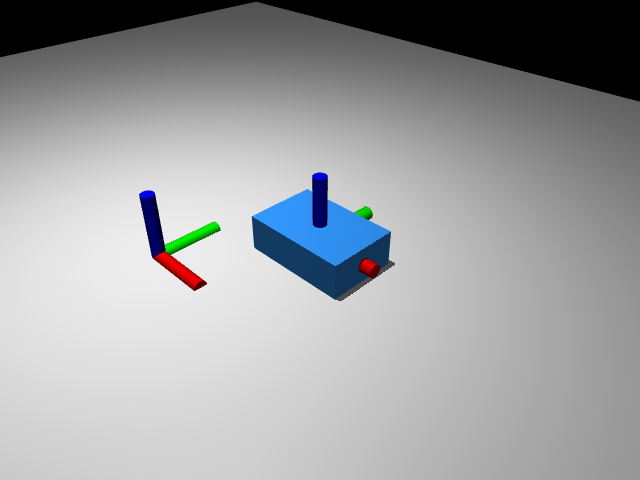
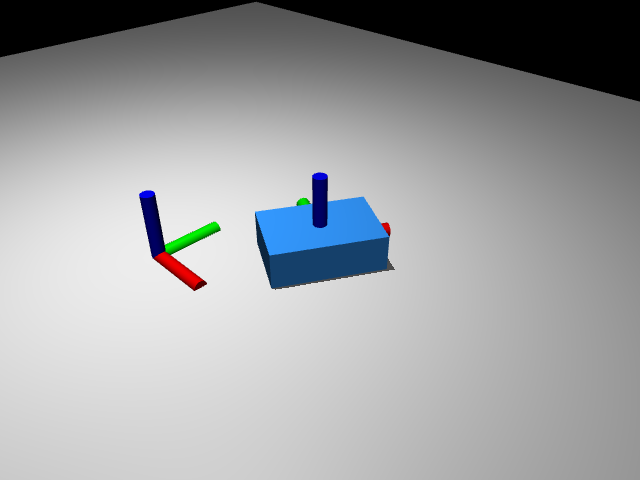

Stage: Z then Y (yaw 60°, pitch 30°)
  Euler ZYX (deg): yaw=60°  pitch=30°  roll=0°


This browser does not support the video tag.


Initial and Final Posistion:


,

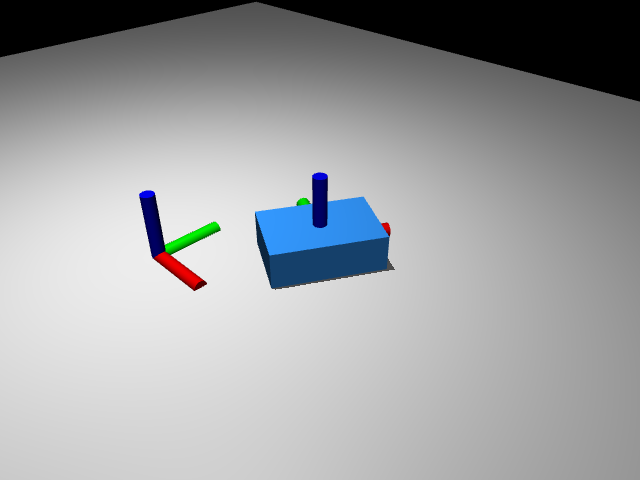
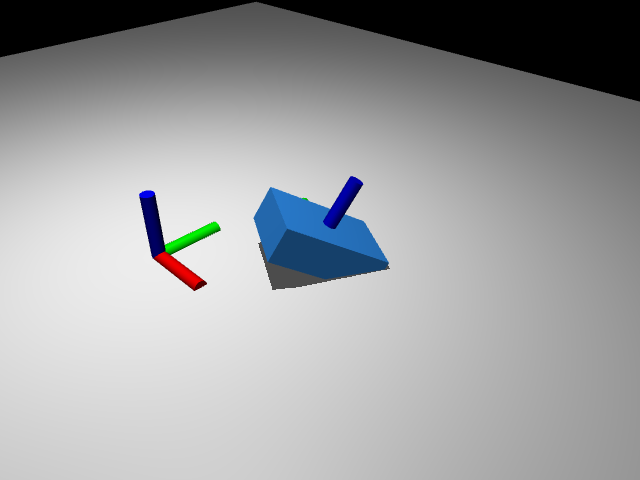

Stage: ZYX (yaw 60°, pitch 30°, roll 20°)
  Euler ZYX (deg): yaw=60°  pitch=30°  roll=20°


This browser does not support the video tag.


Initial and Final Posistion:


,

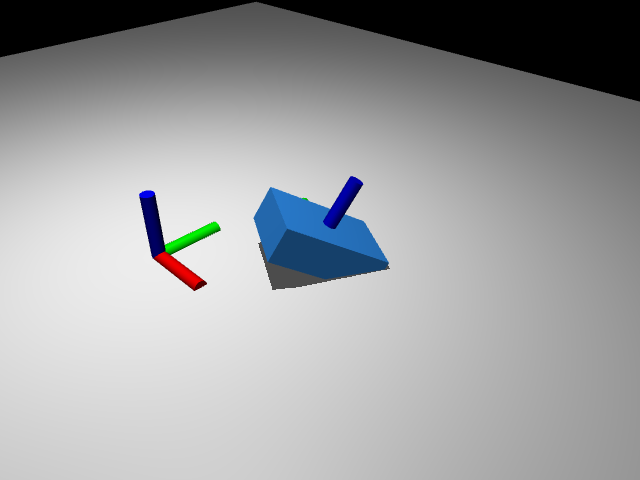
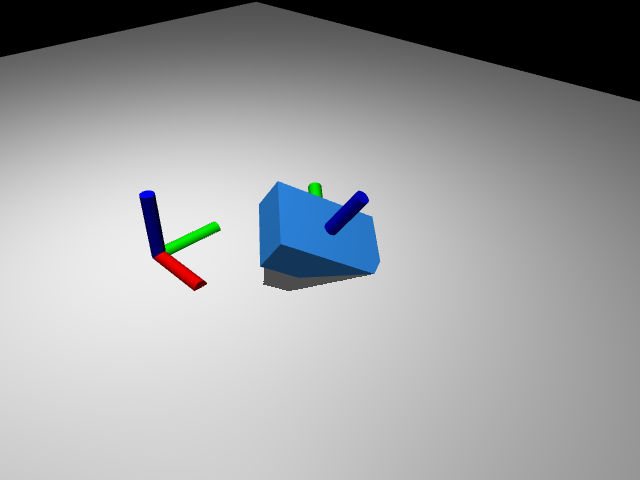

In [7]:
# ------- Rotation Demo: Z → Y → X stages -------
# Keep the block at a fixed position so only rotation changes.
sb_data.qpos[:3] = [0.3, 0.3, 0.05]

opt = mujoco.MjvOption()
opt.frame = mujoco.mjtFrame.mjFRAME_GEOM

cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.distance = 1.5
cam.azimuth = 135
cam.elevation = -35
cam.lookat = [0.3, 0.3, 0.05]

def render_rotation(start_euler, end_euler, label, duration=2, fps=30):
    nframes = int(duration * fps)
    frames = []
    with mujoco.Renderer(sb_model, height=480, width=640) as renderer:
        for i in range(nframes):
            t = i / (nframes - 1)
            euler = start_euler + t * (end_euler - start_euler)
            R = euler_zyx_to_R(*euler)
            sb_data.qpos[3:7] = R_to_quat(R)
            mujoco.mj_forward(sb_model, sb_data)
            renderer.update_scene(sb_data, scene_option=opt, camera=cam)
            frames.append(renderer.render())
    print(f"Stage: {label}")
    print(f"  Euler ZYX (deg): yaw={np.rad2deg(end_euler[0]):.0f}°  pitch={np.rad2deg(end_euler[1]):.0f}°  roll={np.rad2deg(end_euler[2]):.0f}°")
    media.show_video(frames, fps=fps)
    print("Initial and Final Posistion:")
    media.show_images([frames[0], frames[-1]])

identity = np.zeros(3)  # (0,0,0)

# Stage 1: Z-axis rotation only (yaw)
render_rotation(identity, np.deg2rad([60, 0, 0]), "Z‑only (yaw 60°)")

# Stage 2: cumulative Z then Y (yaw + pitch)
render_rotation(np.deg2rad([60, 0, 0]), np.deg2rad([60, 30, 0]), "Z then Y (yaw 60°, pitch 30°)")

# Stage 3: cumulative Z, Y, X (yaw + pitch + roll)
render_rotation(np.deg2rad([60, 30, 0]), np.deg2rad([60, 30, 20]), "ZYX (yaw 60°, pitch 30°, roll 20°)")


#### Rotation Mapping (frame change)

A **mapping** re‑expresses a point from {B} to {A} — no physical motion:

$${}^A P = {}^A_B R \; {}^B P$$

The plot below shows the world frame, the rotated body frame at
$(0.3, 0.3)$ with $\text{yaw} = 45^\circ$, and the point
$^B P = (0.15, 0)$ expressed in both frames.

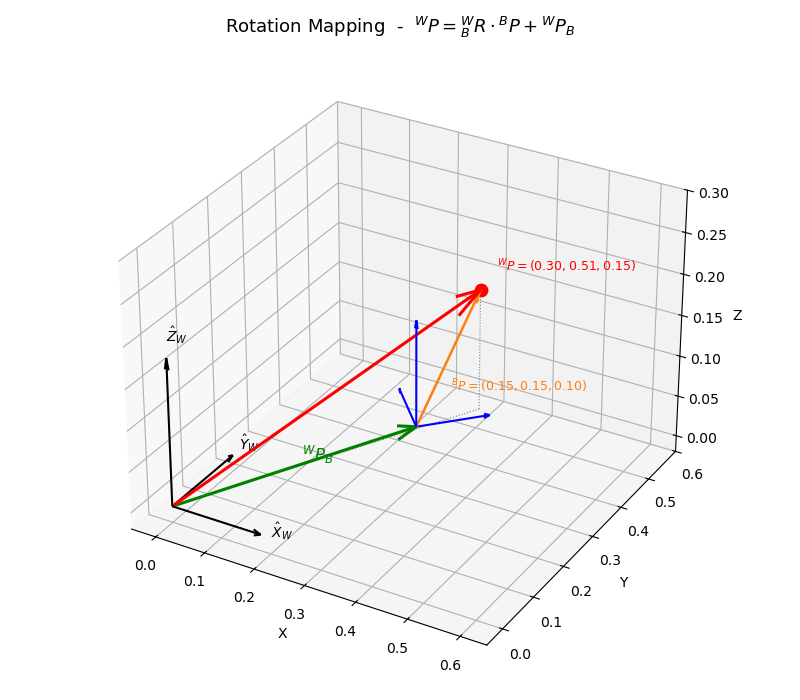

R = R_z(45°)
[[ 0.707 -0.707  0.   ]
 [ 0.707  0.707  0.   ]
 [ 0.     0.     1.   ]]
^W P_B  = (np.float64(0.3), np.float64(0.3), np.float64(0.05))
^B P    = (np.float64(0.15), np.float64(0.15), np.float64(0.1))
^W P    = (np.float64(0.3), np.float64(0.5121), np.float64(0.15))


In [8]:
def plot_rotation_mapping(yaw_deg=45, px=0.15, py=0.15, pz=0.15):
    # Rotation mapping:  ^W P = ^W_B R . ^B P  + ^W P_B
    alpha   = np.deg2rad(yaw_deg)
    origin_B = np.array([0.3, 0.3, 0.05])
    p_in_B  = np.array([px, py, pz])
    Rz = rot_z(alpha)          # rotation about world Z

    # Body axes expressed in world coords
    X_B = Rz @ np.array([0.13, 0, 0])
    Y_B = Rz @ np.array([0, 0.13, 0])
    Z_B = Rz @ np.array([0, 0, 0.13])

    p_rotated = Rz @ p_in_B
    p_in_W    = p_rotated + origin_B

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # ---- world frame {W} ----
    ax.quiver(0, 0, 0, 0.18, 0, 0, color='black', arrow_length_ratio=0.08, lw=1.5)
    ax.quiver(0, 0, 0, 0, 0.18, 0, color='black', arrow_length_ratio=0.08, lw=1.5)
    ax.quiver(0, 0, 0, 0, 0, 0.18, color='black', arrow_length_ratio=0.08, lw=1.5)
    ax.text(0.20, 0.00, 0.00, r'$\hat{X}_W$', fontsize=10)
    ax.text(0.00, 0.20, 0.00, r'$\hat{Y}_W$', fontsize=10)
    ax.text(0.00, 0.00, 0.20, r'$\hat{Z}_W$', fontsize=10)

    # ---- body frame {B} (rotated) ----
    ax.quiver(*origin_B, *X_B, color='blue', arrow_length_ratio=0.08, lw=1.5)
    ax.quiver(*origin_B, *Y_B, color='blue', arrow_length_ratio=0.08, lw=1.5)
    ax.quiver(*origin_B, *Z_B, color='blue', arrow_length_ratio=0.08, lw=1.5)

    # ---- ^W P_B (green) ----
    ax.quiver(0, 0, 0, *origin_B, color='green', arrow_length_ratio=0.08, lw=2.2)
    ax.text(origin_B[0]/2, origin_B[1]/2 + 0.02, origin_B[2]/2,
            r'$^W P_B$', color='green', fontsize=12, weight='bold')

    # ---- ^B P (orange, drawn in body frame, expressed in world) ----
    if np.linalg.norm(p_in_B) > 0.001:
        ax.quiver(*origin_B, *p_rotated, color='#ff7f0e', arrow_length_ratio=0.08, lw=1.8)
    ax.text(origin_B[0] + 0.02, origin_B[1] + 0.08, origin_B[2] + 0.02,
            f'$^B P=({px:.2f},{py:.2f},{pz:.2f})$', fontsize=9, color='#ff7f0e')

    # ---- ^W P (red) ----
    ax.quiver(0, 0, 0, *p_in_W, color='red', arrow_length_ratio=0.08, lw=2.2)
    ax.scatter(*p_in_W, color='red', s=80, zorder=5)
    ax.text(p_in_W[0] + 0.02, p_in_W[1] + 0.02, p_in_W[2] + 0.02,
            f'$^W P=({p_in_W[0]:.2f},{p_in_W[1]:.2f},{p_in_W[2]:.2f})$',
            fontsize=9, color='red')

    # ---- projection helpers ----
    ax.plot([0, p_in_W[0]], [0, p_in_W[1]], [0, 0], ':', color='gray', lw=0.8)
    ax.plot([p_in_W[0], p_in_W[0]], [p_in_W[1], p_in_W[1]],
            [0, p_in_W[2]], ':', color='gray', lw=0.8)

    ax.set_xlim(-0.05, 0.65)
    ax.set_ylim(-0.05, 0.60)
    ax.set_zlim(-0.02, 0.30)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(r'Rotation Mapping  -  $^W P = {}^W_B R \cdot {}^B P + {}^W P_B$',
                 fontsize=13, pad=14)
    plt.tight_layout()
    plt.show()

    print(f"R = R_z({yaw_deg}\u00b0)")
    print(np.round(Rz, 4))
    print(f"^W P_B  = {tuple(np.round(origin_B, 4))}")
    print(f"^B P    = {tuple(np.round(p_in_B,   4))}")
    print(f"^W P    = {tuple(np.round(p_in_W,   4))}")

plot_rotation_mapping(45, 0.15, 0.15, 0.1)

#### Rotation Operator (point moves)

An **operator** rotates a point about an axis *within the same frame* —
the point physically moves:

$$P_2 = R \; P_1$$

The video below rotates the block from $0^\circ$ to $60^\circ$ about $Z$.

In [9]:
P1   = np.array([0.45, 0.35, 0.05])
beta_d = 60
beta = np.deg2rad(beta_d)
R_op = rot_z(beta)
P2   = R_op @ P1
print(f"P1       = {np.round(P1, 4)}")
print(f"R = R_z({beta_d}\u00b0)")
print(np.round(R_op, 4))
print(f"P2 = R\u00b7P1 = {np.round(P2, 4)}")

opt = mujoco.MjvOption()
opt.frame = mujoco.mjtFrame.mjFRAME_GEOM
cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.distance = 1.2
cam.azimuth = 135
cam.elevation = -30
cam.lookat = [0.3, 0.3, 0.05]

duration, fps = 1.5, 30
nframes = int(duration * fps)
frames = []
with mujoco.Renderer(sb_model, height=320, width=480) as r:
    for i in range(nframes):
        t = i / (nframes - 1)
        angle = t * beta
        sb_data.qpos[:3]  = [0.3, 0.3, 0.05]
        sb_data.qpos[3:7] = R_to_quat(rot_z(angle))
        mujoco.mj_forward(sb_model, sb_data)
        r.update_scene(sb_data, scene_option=opt, camera=cam)
        frames.append(r.render())
media.show_video(frames, fps=fps)

P1       = [0.45 0.35 0.05]
R = R_z(60°)
[[ 0.5   -0.866  0.   ]
 [ 0.866  0.5    0.   ]
 [ 0.     0.     1.   ]]
P2 = R·P1 = [-0.078  0.565  0.05 ]


This browser does not support the video tag.


### 0.4  Homogeneous Transform — Pulling It Together

Translation and rotation can be packed into one $4\times4$ matrix:

$${}^A_B T = \begin{bmatrix} {}^A_B R & {}^A P_{B\,\text{org}} \\ 0_{1\times3} & 1 \end{bmatrix}$$

Augment a 3‑vector to a homogeneous vector $P_h = [x,\; y,\; z,\; 1]^\top$:

$${}^A P_h = {}^A_B T \; {}^B P_h$$

One matrix multiply does the rotation *and* translation we previously
did in two steps.  The inverse is:

$${}^B_A T = \begin{bmatrix} {}^A_B R^{\mathsf T} & -{}^A_B R^{\mathsf T}\;{}^A P_{B\,\text{org}} \\ 0 & 1 \end{bmatrix}$$

Below we reuse the rotation from Section 0.3 ($\text{yaw}=45^\circ$,
position $(0.3, 0.3, 0.05)$), verify that $T$ gives the same mapped point,
round‑trip through the inverse, and then **compound** two transforms —
a preview of forward kinematics in Part 2.


In [10]:
def T_from_R_p(R, p):
    T = np.eye(4)
    T[:3, :3] = R
    T[:3,  3] = p
    return T

def inv_T(T):
    R = T[:3, :3]
    p = T[:3,  3]
    Ti = np.eye(4)
    Ti[:3, :3] = R.T
    Ti[:3,  3] = -R.T @ p
    return Ti

def transform_point(T, p):
    ph = np.append(np.asarray(p, dtype=float), 1.0)
    return (T @ ph)[:3]

# ------- Example 1: build T_WB from the Section 0.3 rotation -------
alpha_d, beta_d, gamma_d = 45, 0, 0
R = euler_zyx_to_R(*np.deg2rad([alpha_d, beta_d, gamma_d]))
origin = np.array([0.3, 0.3, 0.05])
T_WB = T_from_R_p(R, origin)
print("T_WB  (block in world) =")
print(np.round(T_WB, 4))

# Verify against manual mapping from Section 0.3
p_local  = np.array([0.15, 0.0, 0.0])
p_via_T  = transform_point(T_WB, p_local)
p_manual = R @ p_local + origin
print(f"\np_local           = {p_local}")
print(f"T \u00b7 p_h        = {np.round(p_via_T, 4)}")
print(f"R\u00b7p + origin (manual) = {np.round(p_manual, 4)}")
print(f"Match: {np.allclose(p_via_T, p_manual)}")

# ------- Example 2: invert T_WB to get T_BW -------
T_BW = inv_T(T_WB)
print(f"\nT_BW  (world in block) =")
print(np.round(T_BW, 4))

# Round‑trip: map the world point back to local
p_world = p_via_T
p_back  = transform_point(T_BW, p_world)
print(f"\nWorld point: {np.round(p_world, 4)}")
print(f"T_BW \u00b7 p_h   = {np.round(p_back, 4)}   (should equal {p_local})")

T_WB  (block in world) =
[[ 0.707 -0.707  0.     0.3  ]
 [ 0.707  0.707  0.     0.3  ]
 [ 0.     0.     1.     0.05 ]
 [ 0.     0.     0.     1.   ]]

p_local           = [0.15 0.   0.  ]
T · p_h        = [0.406 0.406 0.05 ]
R·p + origin (manual) = [0.406 0.406 0.05 ]
Match: True

T_BW  (world in block) =
[[ 0.707  0.707  0.    -0.424]
 [-0.707  0.707  0.    -0.   ]
 [ 0.     0.     1.    -0.05 ]
 [ 0.     0.     0.     1.   ]]

World point: [0.406 0.406 0.05 ]
T_BW · p_h   = [ 0.15 -0.    0.  ]   (should equal [0.15 0.   0.  ])


---

## Part 1 · Spatial Descriptions and Transformations

> **Textbook: Chapter 2** — rotation matrices, mapping between frames, homogeneous transformation arithmetic.

### 1.1  Rotation Matrices — Formal Definition

A rotation matrix $R \in SO(3)$ describes the orientation of frame $\{B\}$ relative to $\{A\}$:

$${}^A_B R = \begin{bmatrix} {}^A\hat{X}_B & {}^A\hat{Y}_B & {}^A\hat{Z}_B \end{bmatrix}$$

Properties: $R^{-1} = R^{\mathsf T}$, $\det(R) = 1$.

In [11]:
theta = np.deg2rad(30)
Rz = rot_z(theta)
print(f"R_z(30°) =\n{Rz}\n")
print(f"det(R) = {np.linalg.det(Rz):.6f}")
print(f"Rᵀ R  = I?  {np.allclose(Rz.T @ Rz, np.eye(3))}")

R_z(30°) =
[[ 0.866 -0.5    0.   ]
 [ 0.5    0.866  0.   ]
 [ 0.     0.     1.   ]]

det(R) = 1.000000
Rᵀ R  = I?  True


### 1.2  Compound Transformations

Given $T^0_1$ (frame 1 in frame 0) and $T^1_2$ (frame 2 in frame 1), the compound transform is:

$$T^0_2 = T^0_1 \, T^1_2$$

In [12]:
T_01 = T_from_R_p(rot_z(np.deg2rad(45)), [2, 0, 0])
T_12 = T_from_R_p(rot_z(np.deg2rad(30)), [1, 0, 0])
T_02 = T_01 @ T_12
print(f"T^0_2 =\n{np.round(T_02, 4)}")

T^0_2 =
[[ 0.259 -0.966  0.     2.707]
 [ 0.966  0.259  0.     0.707]
 [ 0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]]


---

## Part 2 · Forward Kinematics

> **Textbook: Chapter 2** — Denavit–Hartenberg convention, link descriptions, and the forward kinematics equation $${}^0_N T = {}^0_1 T \, {}^1_2 T \cdots {}^{N-1}_N T$$

### 2.1  Denavit–Hartenberg Parameters

Four parameters describe the transform from frame $\{i-1\}$ to frame $\{i\}$:

| Symbol    | Name        | Description                                   |
|-----------|-------------|-----------------------------------------------|
| $a_{i-1}$   | link length | distance $Z_{i-1} \to Z_i$ along $X_{i-1}$    |
| $\alpha_{i-1}$ | link twist  | angle $Z_{i-1} \to Z_i$ about $X_{i-1}$    |
| $d_i$       | link offset | distance $X_{i-1} \to X_i$ along $Z_i$        |
| $\theta_i$   | joint angle | angle $X_{i-1} \to X_i$ about $Z_i$          |

The individual transform (Craig convention) is:

$${}^{i-1}_i T = R_X(\alpha_{i-1})\, D_X(a_{i-1})\, R_Z(\theta_i)\, D_Z(d_i)$$

In [13]:
def dh_transform(a, alpha, d, theta):
    """Homogeneous transform for one DH link (Craig convention)."""
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct,          -st,            0,        a],
        [st * ca,  ct * ca,       -sa,  -sa * d],
        [st * sa,  ct * sa,        ca,   ca * d],
        [0,             0,            0,        1],
    ])

def forward_kinematics_dh(dh_params, joint_angles):
    """dh_params : list of (a, alpha, d, is_revolute).
    joint_angles : array of joint values.
    Returns T^0_N, [T^0_1, T^0_2, ..., T^0_N]."""
    T = np.eye(4)
    frames = [T.copy()]
    for (a, alpha, d, is_rev), q in zip(dh_params, joint_angles):
        theta = q if is_rev else 0
        d_val = d if is_rev else q
        T_i = dh_transform(a, alpha, d_val, theta)
        T = T @ T_i
        frames.append(T.copy())
    return T, frames

### 2.2  3‑Link Planar Arm (RRR)

All joints rotate about $Z$. Link lengths: $L_1 = 0.5$, $L_2 = 0.4$, $L_3 = 0.3$.

| $i$ | $a_{i-1}$ | $\alpha_{i-1}$ | $d_i$ | $\theta_i$ |
|-----|-----------|-----------------|-------|-------------|
| 1   | 0         | 0               | 0     | $\theta_1$  |
| 2   | $L_1$     | 0               | 0     | $\theta_2$  |
| 3   | $L_2$     | 0               | 0     | $\theta_3$  |
| EE  | $L_3$     | 0               | 0     | 0           |

In [17]:
L1, L2, L3 = 0.5, 0.4, 0.3

# DH params: (a, alpha, d, is_revolute)
dh_planar = [
    (0,   0, 0, True),   # link 1
    (L1,  0, 0, True),   # link 2
    (L2,  0, 0, True),   # link 3
    (L3,  0, 0, False),  # tool
]

def fk_analytic(theta1, theta2, theta3, _):
    """Direct trigonometric FK for the 3-link planar arm."""
    x = L1*np.cos(theta1) + L2*np.cos(theta1+theta2) + L3*np.cos(theta1+theta2+theta3)
    y = L1*np.sin(theta1) + L2*np.sin(theta1+theta2) + L3*np.sin(theta1+theta2+theta3)
    phi = theta1 + theta2 + theta3
    return np.array([x, y, 0.0]), phi

In [18]:
q = np.array([0.5, 0.8, -0.3, 0])
T_ee, frames = forward_kinematics_dh(dh_planar, q)
ee_dh = T_ee[:3, 3]
ee_tri, phi = fk_analytic(*q)

print(f"Joint angles θ  = {q}")
print(f"DH FK position   = {np.round(ee_dh, 6)}")
print(f"Trig FK position = {np.round(ee_tri, 6)}")
print(f"Match: {np.allclose(ee_dh, ee_tri)}")
print(f"EE orientation φ = {phi:.3f} rad = {np.rad2deg(phi):.1f}°")

Joint angles θ  = [ 0.5  0.8 -0.3  0. ]
DH FK position   = [0.708 0.878 0.   ]
Trig FK position = [0.708 0.878 0.   ]
Match: True
EE orientation φ = 1.000 rad = 57.3°


---

## Part 3 · MuJoCo Model and FK Verification

We now verify that `mj_forward()` produces the same FK as our DH computation.

## Preview · The Robot Arm We Will Build

Before diving into the maths, here is the 3‑link planar arm you will learn to model.
Drag the sliders to see how joint angles move the end‑effector.

*(Requires a display. If you are on a headless server, skip this cell.)*

""

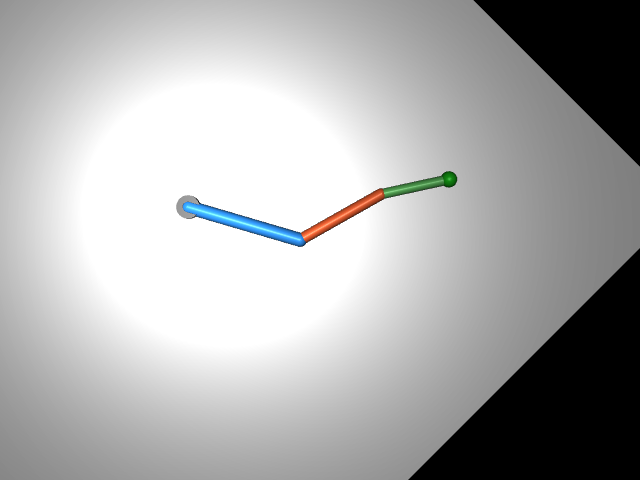

In [19]:
arm3_xml = """
<mujoco model="3dof_planar_arm">
  <compiler angle="radian"/>
  <option gravity="0 0 0"/>
  <worldbody>
    <light name="top" pos="0 0 2"/>
    <geom name="ground" type="plane" size="1.5 1.5 0.01" rgba="0.9 0.9 0.9 1"/>
    <body name="base" pos="0 0 0">
      <geom name="pedestal" type="cylinder" size="0.05 0.02" rgba="0.3 0.3 0.3 1"/>
      <body name="link1" pos="0 0 0">
        <joint name="j1" type="hinge" axis="0 0 1"/>
        <geom name="link1_g" type="capsule" fromto="0 0 0 0.5 0 0" size="0.03" rgba="0.2 0.6 1.0 1"/>
        <body name="link2" pos="0.5 0 0">
          <joint name="j2" type="hinge" axis="0 0 1"/>
          <geom name="link2_g" type="capsule" fromto="0 0 0 0.4 0 0" size="0.025" rgba="1.0 0.4 0.2 1"/>
          <body name="link3" pos="0.4 0 0">
            <joint name="j3" type="hinge" axis="0 0 1"/>
            <geom name="link3_g" type="capsule" fromto="0 0 0 0.3 0 0" size="0.022" rgba="0.4 0.8 0.4 1"/>
            <body name="endeffector" pos="0.3 0 0">
              <geom name="ee_sphere" type="sphere" size="0.035" rgba="0.1 0.8 0.1 1"/>
            </body>
          </body>
        </body>
      </body>
    </body>
  </worldbody>
  <actuator>
    <position name="act1" joint="j1" kp="100"/>
    <position name="act2" joint="j2" kp="100"/>
    <position name="act3" joint="j3" kp="100"/>
  </actuator>
</mujoco>
"""

arm_model = mujoco.MjModel.from_xml_string(arm3_xml)
arm_data  = mujoco.MjData(arm_model)

# Set a sample joint configuration
arm_data.qpos[:] = [0.5, 0.8, -0.3]
mujoco.mj_forward(arm_model, arm_data)

# Configure camera for a nice overview of the arm
cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.distance = 2.5
cam.azimuth = 135
cam.elevation = -90
cam.lookat = [0.5, 0.3, 0]

# Show body frames (geom frames)
opt = mujoco.MjvOption()
#opt.frame = mujoco.mjtFrame.mjFRAME_GEOM

with mujoco.Renderer(arm_model, height=480, width=640) as renderer:
    renderer.update_scene(arm_data, scene_option=opt, camera=cam)
    media.show_image(renderer.render())

### 3.1  Load the Arm Model

The MuJoCo XML was defined in the Preview cell above. We re‑load it here for a clean namespace.

In [20]:
model = mujoco.MjModel.from_xml_string(arm3_xml)
data   = mujoco.MjData(model)
print(f"nbody = {model.nbody}, nv = {model.nv}, nq = {model.nq}")

mujoco.mj_kinematics(model, data)
print('end effector initial position:\n', data.body("endeffector").xpos)
mujoco.mj_resetData(model, data)  # Reset state and time.

nbody = 6, nv = 3, nq = 3
end effector initial position:
 [1.2 0.  0. ]


In [23]:
def fk_mujoco(theta1, theta2, theta3, _):
    data.qpos[:] = [theta1, theta2, theta3]
    mujoco.mj_forward(model, data)
    ee_id = model.body("endeffector").id
    return data.xpos[ee_id].copy(), data.xmat[ee_id].copy().reshape(3, 3)

### 3.2  Compare FK: DH vs. MuJoCo

In [24]:
q = np.array([0.5, 0.8, -0.3, 0])
ee_mj_pos, ee_mj_R = fk_mujoco(*q)

T_ee, _ = forward_kinematics_dh(dh_planar, q)
ee_dh_pos = T_ee[:3, 3]
ee_dh_R   = T_ee[:3, :3]

print(f"DH FK  position: {np.round(ee_dh_pos, 6)}")
print(f"MuJoCo position: {np.round(ee_mj_pos, 6)}")
print(f"Position error : {np.linalg.norm(ee_dh_pos - ee_mj_pos):.2e}\n")

print(f"DH FK  R:\n{np.round(ee_dh_R, 4)}\n")
print(f"MuJoCo R:\n{np.round(ee_mj_R, 4)}\n")
print(f"Orientation error : {np.linalg.norm(ee_dh_R - ee_mj_R):.2e}")

DH FK  position: [0.708 0.878 0.   ]
MuJoCo position: [0.708 0.878 0.   ]
Position error : 2.22e-16

DH FK  R:
[[ 0.54  -0.842  0.   ]
 [ 0.842  0.54   0.   ]
 [ 0.     0.     1.   ]]

MuJoCo R:
[[ 0.54  -0.842  0.   ]
 [ 0.842  0.54   0.   ]
 [ 0.     0.     1.   ]]

Orientation error : 5.44e-16


In [26]:
# Sweep joint space
max_err = 0.0
for t1 in np.linspace(-np.pi, np.pi, 15):
    for t2 in np.linspace(-np.pi, np.pi, 15):
        for t3 in np.linspace(-np.pi, np.pi, 15):
            T, _ = forward_kinematics_dh(dh_planar, [t1, t2, t3])
            pos_mj, _ = fk_mujoco(t1, t2, t3, 0)
            err = np.linalg.norm(T[:3, 3] - pos_mj)
            max_err = max(max_err, err)
print(f"Max FK position error over full joint space: {max_err:.2e}")

Max FK position error over full joint space: 3.00e-01


### 3.3  Reading Frame Information from MuJoCo

For any body, MuJoCo stores:
- `xpos[i]` — world‑frame position
- `xmat[i]` — world‑frame rotation matrix (flattened 3×3)
- `xquat[i]` — world‑frame orientation quaternion $(w, x, y, z)$

These correspond to the $R$ and $P$ blocks of $T^0_i$.

In [27]:
q = [0.5, 0.8, -0.3]
data.qpos[:] = q
mujoco.mj_forward(model, data)

for name in ["link1", "link2", "link3", "endeffector"]:
    bid = model.body(name).id
    pos = data.xpos[bid]
    R   = data.xmat[bid].reshape(3, 3)
    print(f"{name:12s}  pos = {np.round(pos, 4)}  θ_z = {np.arctan2(R[1,0], R[0,0]):.3f} rad")

link1         pos = [0. 0. 0.]  θ_z = 0.500 rad
link2         pos = [0.439 0.24  0.   ]  θ_z = 1.300 rad
link3         pos = [0.546 0.625 0.   ]  θ_z = 1.000 rad
endeffector   pos = [0.708 0.878 0.   ]  θ_z = 1.000 rad


---

## Part 4 · Inverse Kinematics

> **Textbook: Chapter 3** — solvability, closed‑form vs. numerical methods.

For the 3‑link planar arm, the position IK is under‑constrained (redundant). We first solve a 2‑link case analytically, then use the Jacobian pseudo‑inverse for the full 3‑DOF arm.

### 4.1  Closed‑Form IK (2‑Link Arm)

Using the law of cosines on the first two links:

$$\theta_2 = \pm \arccos\left(\frac{x^2 + y^2 - L_1^2 - L_2^2}{2 L_1 L_2}\right)$$

$$\theta_1 = \operatorname{atan2}(y, x) - \operatorname{atan2}(L_2 \sin\theta_2,\; L_1 + L_2 \cos\theta_2)$$

In [ ]:
def ik_2link(target, L1=0.5, L2=0.4, elbow_up=True):
    x, y = target[0], target[1]
    cos_t2 = (x**2 + y**2 - L1**2 - L2**2) / (2 * L1 * L2)
    cos_t2 = np.clip(cos_t2, -1, 1)
    t2 = np.arccos(cos_t2)
    if not elbow_up:
        t2 = -t2
    t1 = np.arctan2(y, x) - np.arctan2(L2 * np.sin(t2), L1 + L2 * np.cos(t2))
    return np.array([t1, t2])

target = np.array([0.7, 0.3])
q_sol = ik_2link(target, elbow_up=True)
ee = fk_analytic(q_sol[0], q_sol[1], 0)[0]

print(f"Target : {target}")
print(f"θ_sol  : {np.round(q_sol, 4)}")
print(f"Reached: {np.round(ee[:2], 4)}")
print(f"Error  : {np.linalg.norm(target - ee[:2]):.2e}")

---

## Summary

| Topic                         | Textbook Ch. | Covered                                                    |
|-------------------------------|:-----------:|------------------------------------------------------------|
| Euler angles & single‑body    | —           | ZYX convention, translation, rotation, homogeneous T       |
| Rotation matrices & transforms| 2           | $R_x,R_y,R_z$, homogeneous transforms, compounding         |
| DH convention & FK            | 3           | DH table → $T^0_N$, verified with MuJoCo                   |
| Inverse kinematics            | 4           | Closed‑form (2‑link)                                       |

**Extensions for subsequent notebooks:**
- 6‑DOF articulated arm (PUMA‑560‑style) with full DH parameterisation
- Dynamics (Chapter 6): Euler–Lagrange, recursive Newton–Euler, `mj_inverse()`
- Trajectory generation and control (Chapters 7–9)